---
title: "Clustering"
format:
  html:
    code-fold: false
---

In [ ]:
#| echo: false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
df =  pd.read_parquet('..\data\logs.parquet')

El clustering es una técnica dentro del aprendizaje no supervisado. Busca clasificar
datos que pertenecen a un mismo conjunto de datos en grupos de características parecidas, al
mismo tiempo que intenta que los grupos resultantes sean lo más diferentes unos de otros.

Además, el clustering es útil para reducir la complejidad de las dimensiones con la ayuda de
aplicar otras técnicas, como el análisis de componentes principales (PCA). De esta forma,
nos permite crear visualizaciones en un plano de dos dimensiones.

Para el análisis de clustering en este apartado, se parte del conjunto de datos inicial, a
partir del cual, crearemos un nuevo conjunto agrupando por la columna Usuario mediante
una consulta que utiliza una cláusula groupby.

El objetivo es representar el comportamiento de cada usuario mediante un conjunto de
variables cuantitativas que sirvan de entrada para el algoritmo.

## Comportamiento de los usuarios
Las variables extraídas resumen la actividad de cada usuario en la aplicación y son las
que se utilizarán para realizar la agrupación. Estas incluyen el número total de eventos (`TotalEventos`), suma de las duraciones de cada sesión en minutos (`DuracionTotal`), cantidad de diseños únicos que el usuario ha creado (`DiseñosUnicos`), número de piezas diferentes añadidas (`PiezasUnicas`), fabricantes distintos (`FabricantesUnicos`) y número de catálogos diferentes
(CatalogosUnicos). Estas variables permiten estudiar el comportamiento de los diferentes usuarios.

In [108]:
usuarios = df.groupby('Usuario')
userdf = pd.DataFrame()
userdf['TotalEventos'] = usuarios.size()
userdf['DuracionTotal'] = usuarios['minutos'].sum()
userdf['DiseñosUnicos'] = usuarios.apply(
        lambda x: x.loc[(x['Evento'] == 'AÑADIR_PIEZA'), 'diseñoid'].nunique(),
        include_groups=False
    )
userdf['PiezasUnicas'] = usuarios.apply(
        lambda x: x.loc[x['Evento'] == 'AÑADIR_PIEZA', 'pieza'].nunique(),
        include_groups=False
    )
userdf['CatalogosUnicos'] = usuarios.apply(
        lambda x: x.loc[x['Evento'] == 'AÑADIR_PIEZA', 'catalogo'].nunique(),
        include_groups=False
    )
userdf['FabricantesUnicos'] = usuarios.apply(
        lambda x: x.loc[x['Evento'] == 'AÑADIR_PIEZA', 'fabricante'].nunique(),
        include_groups=False
    )
userdf

,TotalEventos,DuracionTotal,DiseñosUnicos,PiezasUnicas,CatalogosUnicos,FabricantesUnicos
Usuario,,,,,,
212,9,121.913971,0,0,0,0
3 DESIGN STUDIO,65,1647.199829,3,16,2,1
4.8.1.1.J.C.S.L.,7,60.952118,1,2,1,1
A Coruña,4188,29800.523438,98,770,9,1
A GARCIA MUEBLES,89,905.894470,1,29,4,1
...,...,...,...,...,...,...
severine vetu,108,625.543457,5,32,2,1
sofadekor,337,2767.789795,4,93,7,3
stephane henry,938,4620.505859,13,113,3,1


## Correlación entre variables

Para tener un mejor análisis quito el usuario null, que como acabamos de observar es el que más eventos tiene, ya que registra los eventos de CONEXION y DESCONEXION.

<Axes: >

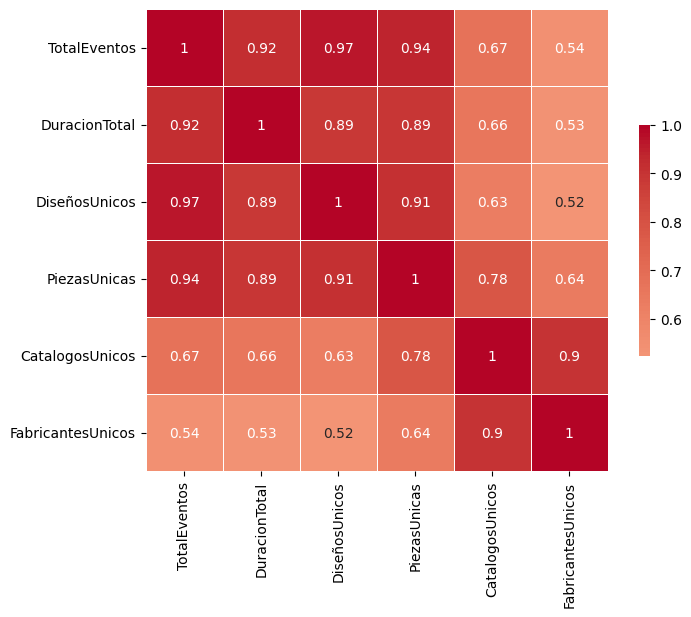

In [109]:
userdf = userdf.drop(index='null')
correlacion_user = userdf.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_user, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [31]:
correlacion_user

,TotalEventos,DuracionTotal,DiseñosUnicos,PiezasUnicas,CatalogosUnicos,FabricantesUnicos
TotalEventos,1.000000,0.915678,0.966098,0.943492,0.673722,0.541375
DuracionTotal,0.915678,1.000000,0.889725,0.893714,0.661144,0.532776
DiseñosUnicos,0.966098,0.889725,1.000000,0.911495,0.633503,0.524064
PiezasUnicas,0.943492,0.893714,0.911495,1.000000,0.784278,0.641157
CatalogosUnicos,0.673722,0.661144,0.633503,0.784278,1.000000,0.904841
FabricantesUnicos,0.541375,0.532776,0.524064,0.641157,0.904841,1.000000


Como observamos en la matriz, hay bastante correlación entre las variables, ya que la
mayoría están próximas a 1, por ello, es útil aplicar el método `PCA()` de la biblioteca sklearn.decomposition
para eliminar la posible redundancia.

## Estandarización y Reducción de Dimensiones con PCA

Aplico `StandardScarler()` sobre mis variables para estandarizar los datos para que todos tengan una escala común, para que unos datos no predominen sobre otros.

In [110]:
scaler = StandardScaler()
userdf[['TotalEventos_T', 'DuracionTotal_T','DiseñosUnicos_T', 'PiezasUnicas_T','CatalogosUnicos_T', 'FabricantesUnicos_T']] = scaler.fit_transform(userdf)
pca = PCA(n_components=2)
pcadf = pca.fit_transform(userdf[['TotalEventos_T', 'DuracionTotal_T','DiseñosUnicos_T', 'PiezasUnicas_T','CatalogosUnicos_T', 'FabricantesUnicos_T']])
userdf[['PC1', 'PC2']] = pcadf
userdf.head()

,TotalEventos,DuracionTotal,DiseñosUnicos,PiezasUnicas,CatalogosUnicos,FabricantesUnicos,TotalEventos_T,DuracionTotal_T,DiseñosUnicos_T,PiezasUnicas_T,CatalogosUnicos_T,FabricantesUnicos_T,PC1,PC2
Usuario,,,,,,,,,,,,,,
212,9,121.913971,0,0,0,0,-0.300706,-0.309258,-0.309027,-0.399147,-0.651789,-0.792359,-1.089080,-0.548808
3 DESIGN STUDIO,65,1647.199829,3,16,2,1,-0.270204,-0.207887,-0.229783,-0.336337,-0.329494,-0.272211,-0.669433,-0.102113
4.8.1.1.J.C.S.L.,7,60.952118,1,2,1,1,-0.301795,-0.313310,-0.282613,-0.391295,-0.490641,-0.272211,-0.836182,-0.122946
A Coruña,4188,29800.523438,98,770,9,1,1.975529,1.663190,2.279629,2.623562,0.798541,-0.272211,3.880226,-1.858609
A GARCIA MUEBLES,89,905.894470,1,29,4,1,-0.257131,-0.257155,-0.282613,-0.285304,-0.007198,-0.272211,-0.558999,0.083787


Se muestra el peso de cada variable para
las dos componentes principales:

In [101]:
variables = ['TotalEventos_T', 'DuracionTotal_T', 'DiseñosUnicos_T', 'PiezasUnicas_T', 'CatalogosUnicos_T', 'FabricantesUnicos_T']
componentes = pd.DataFrame(pca.components_, columns=variables, index=['PC1', 'PC2'])
print(componentes)

     TotalEventos_T  DuracionTotal_T  DiseñosUnicos_T  PiezasUnicas_T  \
PC1        0.465445    -2.220446e-16         0.457012        0.481407   
PC2       -0.383072    -1.942890e-16        -0.394947       -0.213375   

     CatalogosUnicos_T  FabricantesUnicos_T  
PC1           0.438176             0.388266  
PC2           0.474546             0.653108  


## Método del codo

El método del codo (*Elbow Method*) es una técnica que se usa para determinar el número óptimo de grupos K de forma visual.


In [111]:
def optimise_k_means(data, max_k):
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
    plt.subplots(figsize = (10, 5))
    plt.plot(range(1, max_k), inertias, 'o-')
    plt.show()

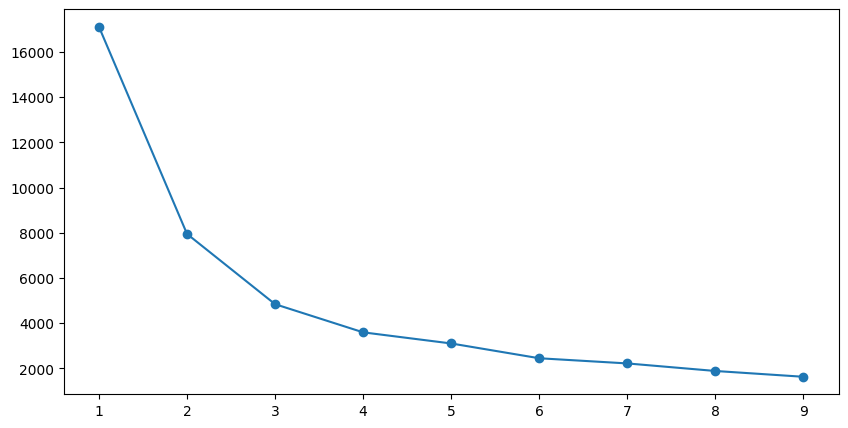

In [112]:
optimise_k_means(userdf[['PC1', 'PC2']], 10)

Como puede observarse, el punto donde el “codo” empieza a ser menos pronunciado es a partir de K = 3, que será el K que vamos a usar para aplicar el algoritmo
K-Mean

## Algoritmo K-Means

El algoritmo K-Means es muy usado debido a su eficiencia y simpleza. Es un método
de clustering basado en centroides, su funcionamiento se basa en encontrar un número K de
grupos, de manera que cada observación esté lo más cerca del centro del centroide asignado
a su grupo. El objetivo de K-Means es reducir al máximo la suma de las distancias cuadradas
entre cada punto y el centro de su clúster.

La función objetivo que el algoritmo minimiza (inercia) es:

$$
J = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2
$$

Donde:
- $K$ = número de grupos.
- $C_k$ = conjunto de puntos asignados al grupo $K$.
- $x_i$ = vector de características del punto $i$.
- $\mu_k$ = centroide del grupo $k$
- $||x_i - \mu _k||^2$ = distancia euclidiana al cuadrado entre el punto y el centroide

Siendo $\mu_k$ calculado:
$$
\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i
$$


In [113]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(userdf[['PC1','PC2']])
userdf['kmeans_pca'] = kmeans.labels_

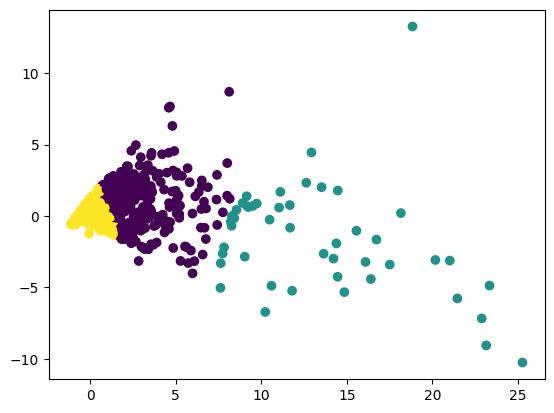

In [114]:
plt.scatter(x=userdf.PC1, y=userdf.PC2, c=userdf.kmeans_pca)
plt.show()

Se han identificado tres grupos de usuarios distintos, basándose en la influencia que cada componente principal tiene sobre las variables analizadas:

- **Clúster Verde Azulado:** Estos usuarios se sitúan en valores negativos o muy bajos de PC1 (poca actividad global: pocos eventos, duración escasa, diseños y piezas mínimas) y PC2 (exploración limitada de catálogos y fabricantes). Representan un perfil de usuario que puede ser nuevo en la aplicación.

- **Clúster Morado:** Las puntuaciones intermedias en PC1 y PC2 indican valores promedio en todas las métricas de actividad (eventos, duración, diseños, piezas) y diversidad (catálogos, fabricantes). Este grupo representa el comportamiento estándar de los usuarios de la plataforma.

- **Clúster Amarillo:** Agrupa a los usuarios con los valores más altos en PC1, lo que significa que son los más activos dentro de la plataforma y con basante variabilidad en PC2 aunque la mayoría está en negativo lo que significa que usan pocos fabricantes y catálogos.

## Evaluación del Clustering

In [105]:
print("Contribucion de cada componente:", pca.explained_variance_ratio_)

Contribucion de cada componente: [0.7919951  0.16963676]


El `silhouette_score` es una medida que nos indica como de bien se han agrupado los datos, teniendo en cuenta la distancia de un punto con los demás puntos de su grupo y la distancia al grupo vecino más cercano.

In [106]:
silhouette_avg = silhouette_score(userdf[['PC1', 'PC2']], userdf['kmeans_pca'])
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.7445436921126249


- Silhouette Score: +1. Indica que los clusters estan perfectamente agrupados.

- Silhouette Score: 0. Indica que hay solapamiento y es difícil distinguir entre dos grupos.

- Silhouette Score: -1. Indica que los puntos están más cercanos a otro grupo que al suyo mismo.
